<a href="https://colab.research.google.com/github/Ginormous712/AI/blob/master/NLP_Toxic_Comments_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота: Класифікація токсичних коментарів
## Порівняння трьох підходів NLP: TF-IDF → distilBERT → LLM Few-Shot

**Датасет:** Jigsaw Toxic Comment Classification (Kaggle)  
**Мова реалізації:** Python 3.11  
**Середовище:** Google Colab / Jupyter Notebook

---
| Рівень | Метод | Бібліотека |
|--------|-------|------------|
| 1 — Baseline | TF-IDF + Logistic Regression | scikit-learn |
| 2 — Deep Learning | distilBERT Fine-tuning | transformers, torch |
| 3 — Advanced | LLM Few-Shot Prompting | anthropic / openai |


## 0. Встановлення залежностей

In [1]:
# Встановлення всіх необхідних бібліотек
!pip install kagglehub pandas numpy matplotlib seaborn wordcloud scikit-learn --quiet
!pip install transformers torch accelerate --quiet
!pip install anthropic openai --quiet

print('✅ Залежності встановлено')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.6/838.6 kB 27.3 MB/s eta 0:00:00
✅ Залежності встановлено


## 1. Завантаження та первинний аналіз датасету (EDA)

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import time

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Завантаження датасету ───────────────────────────────
print('⬇️  Завантаження датасету з Kaggle...')
path = kagglehub.dataset_download(
    'julian3833/jigsaw-toxic-comment-classification-challenge'
)
print(f'✅ Шлях: {path}')

# ── Завантаження CSV ────────────────────────────────────
train_csv = os.path.join(path, 'train.csv')
df = pd.read_csv(train_csv)

print(f'\n📊 Розмір датасету: {df.shape}')
print(f'Колонки: {df.columns.tolist()}')
df.head(3)

⬇️  Завантаження датасету з Kaggle...


100%|██████████| 53.4M/53.4M [00:04<00:00, 12.3MB/s]

Extracting files...


✅ Шлях: /root/.cache/kagglehub/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/versions/1

📊 Розмір датасету: (159571, 8)
Колонки: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


In [3]:
# ── Базова статистика ────────────────────────────────────
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

print('=== Розподіл міток ===')
for col in label_cols:
    n = df[col].sum()
    pct = df[col].mean() * 100
    print(f'  {col:<20}: {n:>6,} ({pct:.2f}%)')

# Бінарна мітка для нашої задачі
df['label'] = df['toxic']
df['text_len'] = df['comment_text'].apply(len)

print(f'\n📝 Середня довжина тексту: {df["text_len"].mean():.0f} символів')
print(f'📝 Медіанна довжина тексту: {df["text_len"].median():.0f} символів')
print(f'\nДисбаланс класів: {df["label"].mean()*100:.1f}% токсичних')

=== Розподіл міток ===
  toxic               : 15,294 (9.58%)
  severe_toxic        :  1,595 (1.00%)
  obscene             :  8,449 (5.29%)
  threat              :    478 (0.30%)
  insult              :  7,877 (4.94%)
  identity_hate       :  1,405 (0.88%)

📝 Середня довжина тексту: 394 символів
📝 Медіанна довжина тексту: 205 символів

Дисбаланс класів: 9.6% токсичних


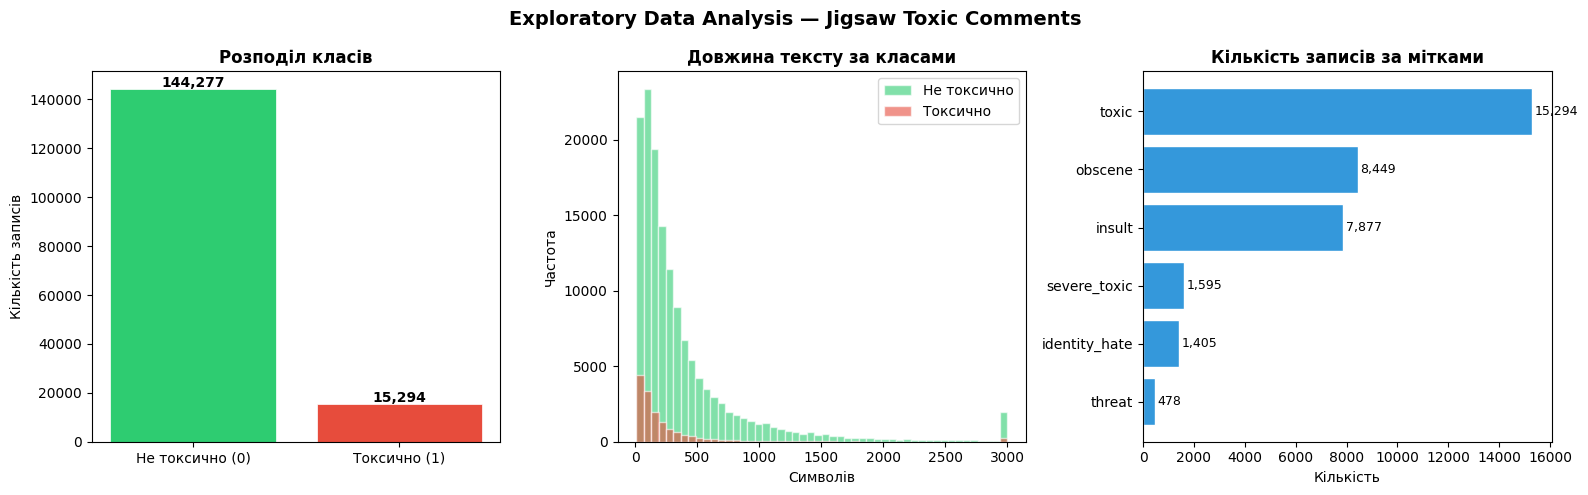

✅ EDA збережено: eda_overview.png


In [4]:
# ── Візуалізація EDA ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Exploratory Data Analysis — Jigsaw Toxic Comments', fontsize=14, fontweight='bold')

# 1. Розподіл класів
counts = df['label'].value_counts()
bars = axes[0].bar(['Не токсично (0)', 'Токсично (1)'], counts.values,
                    color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Розподіл класів', fontweight='bold')
axes[0].set_ylabel('Кількість записів')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 800, f'{v:,}',
                 ha='center', fontweight='bold')

# 2. Розподіл довжини тексту
for label, color, name in [(0, '#2ecc71', 'Не токсично'), (1, '#e74c3c', 'Токсично')]:
    subset = df[df['label'] == label]['text_len'].clip(upper=3000)
    axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=name, edgecolor='white')
axes[1].set_title('Довжина тексту за класами', fontweight='bold')
axes[1].set_xlabel('Символів')
axes[1].set_ylabel('Частота')
axes[1].legend()

# 3. Розподіл усіх міток
label_counts = df[label_cols].sum().sort_values(ascending=True)
axes[2].barh(label_counts.index, label_counts.values,
              color='#3498db', edgecolor='white')
axes[2].set_title('Кількість записів за мітками', fontweight='bold')
axes[2].set_xlabel('Кількість')
for i, v in enumerate(label_counts.values):
    axes[2].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA збережено: eda_overview.png')

## 2. Препроцесинг та підготовка даних

In [5]:
import re
from sklearn.model_selection import train_test_split

# ── Функція очищення тексту ──────────────────────────────
def clean_text(text: str) -> str:
    """Базове очищення тексту для TF-IDF та LLM."""
    # Видалення HTML-тегів
    text = re.sub(r'<[^>]+>', ' ', text)
    # Видалення URL
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # Видалення спецсимволів (залишаємо літери, цифри, пробіли)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    # Нормалізація пробілів
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

# ── Застосування очищення ────────────────────────────────
print('Очищення тексту...')
df['clean_text'] = df['comment_text'].apply(clean_text)

# ── Збалансована вибірка ─────────────────────────────────
# Беремо всі токсичні + 3× більше нетоксичних (реалістичний дисбаланс 1:3)
toxic_df = df[df['label'] == 1]
non_toxic_df = df[df['label'] == 0].sample(n=len(toxic_df) * 3, random_state=42)
df_balanced = pd.concat([toxic_df, non_toxic_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\n✅ Збалансована вибірка: {df_balanced.shape}')
print(df_balanced['label'].value_counts().to_string())

# ── Train / Test split ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['clean_text'],
    df_balanced['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_balanced['label']
)

# Оригінальний текст для BERT та LLM (без aggressive cleaning)
X_train_raw = df_balanced.loc[X_train.index, 'comment_text']
X_test_raw  = df_balanced.loc[X_test.index, 'comment_text']

print(f'\nТренувальна вибірка: {len(X_train):,}')
print(f'Тестова вибірка:     {len(X_test):,}')

Очищення тексту...

✅ Збалансована вибірка: (61176, 11)
label
0    45882
1    15294

Тренувальна вибірка: 48,940
Тестова вибірка:     12,236


---
# РІВЕНЬ 1: Baseline — TF-IDF + Logistic Regression
> **Підхід:** Перетворення тексту в числовий вектор через TF-IDF, класифікація через Logistic Regression з scikit-learn. Жодних нейронних мереж — чисте старе ML.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import time

# ── Конфігурація TF-IDF ──────────────────────────────────
# max_features: розмір словника (top-50k слів)
# ngram_range: unigrams та bigrams для кращого контексту
# sublinear_tf: логарифмічне масштабування TF
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode'
)

# ── Конфігурація Logistic Regression ────────────────────
# C=1.0: регуляризація (більше C = менше регуляризації)
# max_iter=1000: достатньо для збіжності
# class_weight='balanced': компенсація дисбалансу класів
lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42
)

# ── Pipeline: TF-IDF → LogReg ────────────────────────────
pipeline_l1 = Pipeline([
    ('tfidf', tfidf),
    ('clf',   lr)
])

# ── Навчання ─────────────────────────────────────────────
print('Навчання TF-IDF + Logistic Regression...')
t0 = time.time()
pipeline_l1.fit(X_train, y_train)
train_time_l1 = time.time() - t0
print(f'✅ Час навчання: {train_time_l1:.1f} сек')

# ── Оцінка на тестовій вибірці ───────────────────────────
y_pred_l1 = pipeline_l1.predict(X_test)

acc_l1  = accuracy_score(y_test, y_pred_l1)
prec_l1 = precision_score(y_test, y_pred_l1, average='macro')
rec_l1  = recall_score(y_test, y_pred_l1, average='macro')
f1_l1   = f1_score(y_test, y_pred_l1, average='macro')

print(f'\n=== РЕЗУЛЬТАТИ РІВНЯ 1 ===')
print(f'Accuracy:  {acc_l1:.4f} ({acc_l1*100:.1f}%)')
print(f'Precision: {prec_l1:.4f}')
print(f'Recall:    {rec_l1:.4f}')
print(f'F1-Score:  {f1_l1:.4f}')
print(f'\nДетальний звіт:')
print(classification_report(y_test, y_pred_l1, target_names=['Не токсично', 'Токсично']))

Навчання TF-IDF + Logistic Regression...
✅ Час навчання: 19.6 сек

=== РЕЗУЛЬТАТИ РІВНЯ 1 ===
Accuracy:  0.9184 (91.8%)
Precision: 0.8874
Recall:    0.8987
F1-Score:  0.8928

Детальний звіт:
              precision    recall  f1-score   support

 Не токсично       0.95      0.94      0.95      9177
    Токсично       0.82      0.86      0.84      3059

    accuracy                           0.92     12236
   macro avg       0.89      0.90      0.89     12236
weighted avg       0.92      0.92      0.92     12236



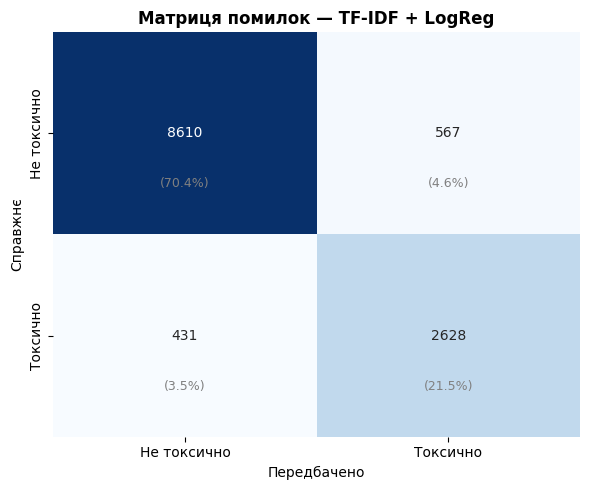

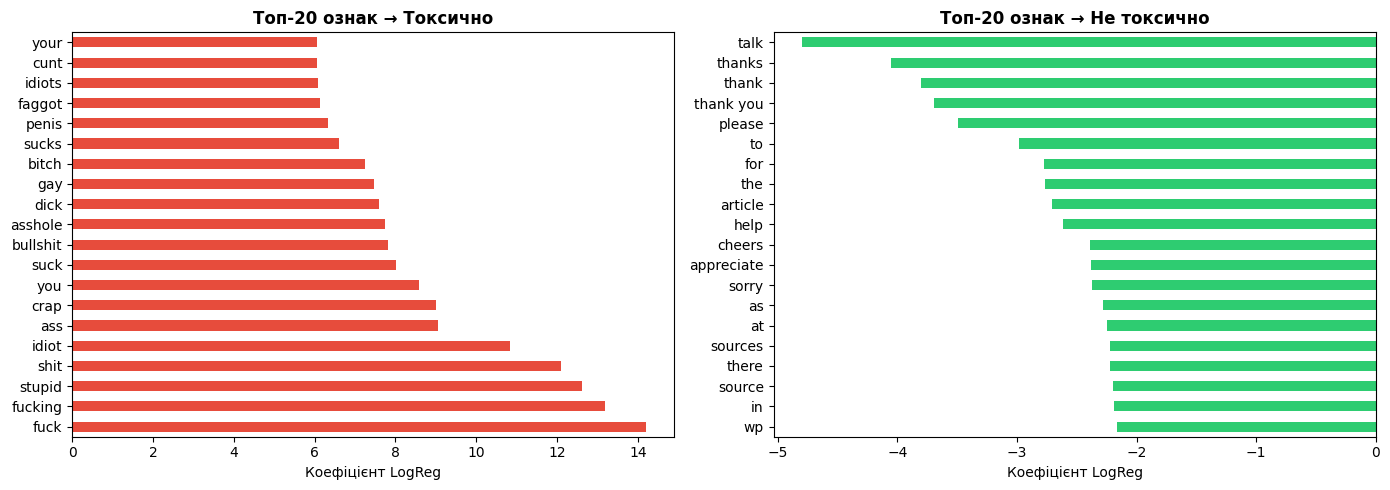

In [7]:
# ── Матриця помилок для Рівня 1 ──────────────────────────
def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Не токсично', 'Токсично'],
                yticklabels=['Не токсично', 'Токсично'],
                ax=ax, cbar=False)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Передбачено')
    ax.set_ylabel('Справжнє')
    # Відсотки
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.75, f'({cm[i,j]/total*100:.1f}%)',
                    ha='center', va='center', fontsize=9, color='gray')

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
plot_confusion_matrix(y_test, y_pred_l1, 'Матриця помилок — TF-IDF + LogReg', ax)
plt.tight_layout()
plt.savefig('cm_level1.png', dpi=150)
plt.show()

# ── Топ-20 найважливіших слів ─────────────────────────────
feature_names = pipeline_l1.named_steps['tfidf'].get_feature_names_out()
coef = pipeline_l1.named_steps['clf'].coef_[0]

top_toxic     = pd.Series(coef, index=feature_names).nlargest(20)
top_non_toxic = pd.Series(coef, index=feature_names).nsmallest(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_toxic.plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Топ-20 ознак → Токсично', fontweight='bold')
axes[0].set_xlabel('Коефіцієнт LogReg')

top_non_toxic[::-1].plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Топ-20 ознак → Не токсично', fontweight='bold')
axes[1].set_xlabel('Коефіцієнт LogReg')

plt.tight_layout()
plt.savefig('features_level1.png', dpi=150)
plt.show()

---
# РІВЕНЬ 2: Deep Learning — distilBERT Fine-tuning
> **Підхід:** Fine-tuning попередньо навченої моделі distilBERT (HuggingFace). Використовуємо [CLS] токен як представлення всього тексту та додаємо лінійний класифікатор зверху.
>
> **Вимоги:** GPU рекомендовано (Google Colab T4/A100). На CPU час навчання ~2–3 години.

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

# ── Перевірка GPU ────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Пристрій: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Гіперпараметри ───────────────────────────────────────
MODEL_NAME  = 'distilbert-base-uncased'  # 66M параметрів
MAX_LENGTH  = 256    # максимальна кількість токенів
BATCH_SIZE  = 16     # зменшити до 8 якщо OOM
EPOCHS      = 3
LR          = 2e-5   # стандартний для fine-tuning BERT
WARMUP_RATIO = 0.1   # 10% кроків — warmup

# ── Токенізатор ──────────────────────────────────────────
print(f'\nЗавантаження токенізатора: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('✅ Токенізатор готовий')

Пристрій: cuda
GPU: Tesla T4
VRAM: 15.6 GB

Завантаження токенізатора: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ Токенізатор готовий


In [9]:
# ── Dataset клас для PyTorch ─────────────────────────────
class ToxicDataset(Dataset):
    """PyTorch Dataset для токсичних коментарів."""

    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = list(texts)
        self.labels     = list(labels)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Токенізація одного тексту
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ── Створення DataLoader-ів ──────────────────────────────
train_dataset = ToxicDataset(X_train_raw.values, y_train.values, tokenizer, MAX_LENGTH)
test_dataset  = ToxicDataset(X_test_raw.values,  y_test.values,  tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 3059
Test batches:  765


In [10]:
# ── Завантаження моделі distilBERT ──────────────────────
print(f'Завантаження моделі: {MODEL_NAME}')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,          # binary: 0/1
    ignore_mismatched_sizes=True
)
model = model.to(DEVICE)

# Кількість параметрів
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Всього параметрів: {total_params:,}')
print(f'Навчаємих:         {trainable:,}')

# ── Оптимізатор і планувальник ───────────────────────────
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
print(f'\nВсього кроків: {total_steps} | Warmup: {warmup_steps}')

Завантаження моделі: distilbert-base-uncased


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Всього параметрів: 66,955,010
Навчаємих:         66,955,010

Всього кроків: 9177 | Warmup: 917


In [11]:
# ── Функції тренування та оцінки ─────────────────────────
def train_epoch(model, loader, optimizer, scheduler, device):
    """Одна епоха навчання."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for step, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        loss.backward()

        # Gradient clipping — запобігає вибуху градієнтів
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if (step + 1) % 100 == 0:
            print(f'  Крок {step+1}/{len(loader)} | '
                  f'Loss: {total_loss/(step+1):.4f} | '
                  f'Acc: {correct/total:.4f}')

    return total_loss / len(loader), correct / total


def eval_model(model, loader, device):
    """Оцінка моделі на вибірці."""
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
            total_loss += outputs.loss.item()
            all_preds.extend(outputs.logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (
        total_loss / len(loader),
        np.array(all_preds),
        np.array(all_labels)
    )

print('✅ Функції навчання готові')

✅ Функції навчання готові


In [12]:
# ── Навчання distilBERT (3 епохи) ───────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_f1': []}

print(f'Починаємо навчання | Пристрій: {DEVICE} | Епох: {EPOCHS}')
print('=' * 60)

t0_total = time.time()
best_f1  = 0.0

for epoch in range(1, EPOCHS + 1):
    print(f'\nЕпоха {epoch}/{EPOCHS}')
    t0_epoch = time.time()

    # Тренування
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)

    # Оцінка
    val_loss, val_preds, val_labels = eval_model(model, test_loader, DEVICE)
    val_f1 = f1_score(val_labels, val_preds, average='macro')

    epoch_time = time.time() - t0_epoch
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_f1'].append(val_f1)

    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'  Val Loss:   {val_loss:.4f}   | Val F1:    {val_f1:.4f}')
    print(f'  Час епохи:  {epoch_time/60:.1f} хв')

    # Збереження найкращої моделі
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), 'best_bert_model.pt')
        print(f'  Збережено найкращу модель (F1={best_f1:.4f})')

train_time_l2 = time.time() - t0_total
print(f'\n✅ Навчання завершено за {train_time_l2/60:.1f} хв')

Починаємо навчання | Пристрій: cuda | Епох: 3

Епоха 1/3
  Крок 100/3059 | Loss: 0.7123 | Acc: 0.4194
  Крок 200/3059 | Loss: 0.5768 | Acc: 0.6125
  Крок 300/3059 | Loss: 0.4682 | Acc: 0.7119
  Крок 400/3059 | Loss: 0.4009 | Acc: 0.7641
  Крок 500/3059 | Loss: 0.3579 | Acc: 0.7964
  Крок 600/3059 | Loss: 0.3302 | Acc: 0.8187
  Крок 700/3059 | Loss: 0.3079 | Acc: 0.8357
  Крок 800/3059 | Loss: 0.2945 | Acc: 0.8466
  Крок 900/3059 | Loss: 0.2832 | Acc: 0.8558
  Крок 1000/3059 | Loss: 0.2740 | Acc: 0.8638
  Крок 1100/3059 | Loss: 0.2627 | Acc: 0.8712
  Крок 1200/3059 | Loss: 0.2561 | Acc: 0.8769
  Крок 1300/3059 | Loss: 0.2475 | Acc: 0.8825
  Крок 1400/3059 | Loss: 0.2421 | Acc: 0.8865
  Крок 1500/3059 | Loss: 0.2366 | Acc: 0.8900
  Крок 1600/3059 | Loss: 0.2336 | Acc: 0.8923
  Крок 1700/3059 | Loss: 0.2289 | Acc: 0.8949
  Крок 1800/3059 | Loss: 0.2246 | Acc: 0.8976
  Крок 1900/3059 | Loss: 0.2215 | Acc: 0.8997
  Крок 2000/3059 | Loss: 0.2187 | Acc: 0.9019
  Крок 2100/3059 | Loss: 0.2153 

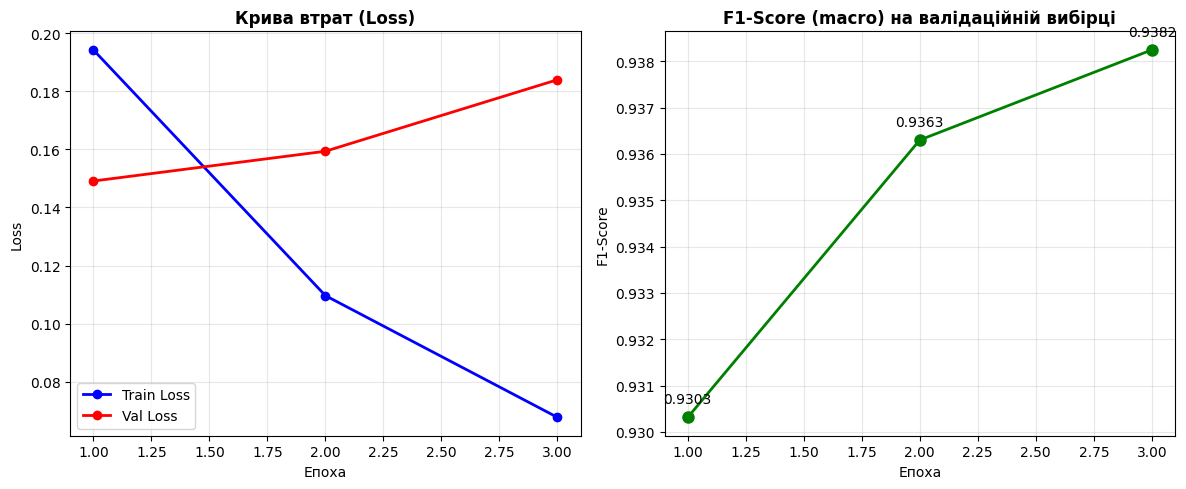


=== РЕЗУЛЬТАТИ РІВНЯ 2 (distilBERT) ===
Accuracy:  0.9535 (95.3%)
Precision: 0.9365
Recall:    0.9400
F1-Score:  0.9382

              precision    recall  f1-score   support

 Не токсично       0.97      0.97      0.97      9177
    Токсично       0.90      0.91      0.91      3059

    accuracy                           0.95     12236
   macro avg       0.94      0.94      0.94     12236
weighted avg       0.95      0.95      0.95     12236



In [13]:
# ── Крива навчання ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
axes[0].set_title('Крива втрат (Loss)', fontweight='bold')
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['val_f1'], 'g-o', linewidth=2, markersize=8)
axes[1].set_title('F1-Score (macro) на валідаційній вибірці', fontweight='bold')
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('F1-Score')
axes[1].grid(alpha=0.3)
for ep, f1 in zip(epochs_range, history['val_f1']):
    axes[1].annotate(f'{f1:.4f}', (ep, f1), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('training_curve_bert.png', dpi=150)
plt.show()

# ── Фінальна оцінка з найкращою моделлю ─────────────────
model.load_state_dict(torch.load('best_bert_model.pt', map_location=DEVICE))
_, y_pred_l2, y_true_l2 = eval_model(model, test_loader, DEVICE)

acc_l2  = accuracy_score(y_true_l2, y_pred_l2)
prec_l2 = precision_score(y_true_l2, y_pred_l2, average='macro')
rec_l2  = recall_score(y_true_l2, y_pred_l2, average='macro')
f1_l2   = f1_score(y_true_l2, y_pred_l2, average='macro')

print(f'\n=== РЕЗУЛЬТАТИ РІВНЯ 2 (distilBERT) ===')
print(f'Accuracy:  {acc_l2:.4f} ({acc_l2*100:.1f}%)')
print(f'Precision: {prec_l2:.4f}')
print(f'Recall:    {rec_l2:.4f}')
print(f'F1-Score:  {f1_l2:.4f}')
print(f'\n{classification_report(y_true_l2, y_pred_l2, target_names=["Не токсично", "Токсично"])}')

# РІВЕНЬ 3: Advanced — LLM Few-Shot Prompting (Flan-T5-XL)
> **Підхід:** Використання instruction-tuned моделі Google Flan-T5-XL (3B параметрів) з few-shot прикладами у промпті. Модель **не проходить fine-tuning** — ми надаємо 5 прикладів безпосередньо в тексті запиту (in-context learning). Це демонструє здатність LLM розуміти завдання лише за прикладами.
>
> **Вимоги:** GPU (T4/A100 у Google Colab). VRAM: ~6 GB (fp16). Завантаження: ~10 хв.

In [31]:
# ── Завантаження Flan-T5-XL ─────────────────────────────
# Google Flan-T5-XL: 3B параметрів, instruction-tuned на 1800+ завданнях
# Використовуємо float16 для економії VRAM (~6 GB на GPU)
from transformers import T5ForConditionalGeneration, AutoTokenizer
import torch

MODEL_T5 = 'google/flan-t5-xl'  # 3B параметрів

print(f'Завантаження: {MODEL_T5}')
print('(при першому запуску ~5-10 хв для завантаження ваг)')

t5_tokenizer = AutoTokenizer.from_pretrained(MODEL_T5)

model_t5 = T5ForConditionalGeneration.from_pretrained(
    MODEL_T5,
    device_map='auto',          # автоматично GPU якщо доступне
    torch_dtype=torch.float16  # fp16: менше VRAM, та сама якість
)
model_t5.eval()  # режим inference (вимикає dropout)

LLM_PROVIDER = 'flant5'

device_str = str(next(model_t5.parameters()).device)
print(f'\n✅ {MODEL_T5} завантажено!')
print(f'   Пристрій: {device_str}')
print(f'   Провайдер: {LLM_PROVIDER}')
if 'cuda' in device_str:
    used = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'   VRAM: {used:.1f} / {total:.1f} GB')

Завантаження: google/flan-t5-xl
(при першому запуску ~5-10 хв для завантаження ваг)


config.json:   0%|          | 0.00/1.44k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


✅ google/flan-t5-xl завантажено!
   Пристрій: cuda:0
   Провайдер: flant5
   VRAM: 9.5 / 15.6 GB


In [32]:
# ── Few-Shot промпт ──────────

FEW_SHOT_EXAMPLES = [
    {"text": "I love Wikipedia! It is a great resource for learning.",
     "label": "SAFE"},
    {"text": "You are a complete idiot and should go kill yourself.",
     "label": "TOXIC"},
    {"text": "This article needs more citations and references.",
     "label": "SAFE"},
    {"text": "Die you worthless piece of garbage, nobody wants you here.",
     "label": "TOXIC"},
    {"text": "Can someone please help me understand this concept better?",
     "label": "SAFE"},
    {"text": "Shut up you stupid moron, your edits are garbage.",
     "label": "TOXIC"},
    {"text": "Thank you for your contribution to this discussion.",
     "label": "SAFE"},
]

SYSTEM_PROMPT = """You are a content moderation assistant.
Your task is to classify text comments as TOXIC or SAFE.
TOXIC: comments containing insults, threats, hate speech, harassment, or explicit harmful content.
SAFE: comments that are neutral, constructive, or positive.
Respond with ONLY one word: either TOXIC or SAFE. No explanations."""

def build_few_shot_prompt(text: str) -> str:
    """Побудова few-shot промпту для Flan-T5.

    Flan-T5 найкраще розуміє формат:
    - Чітка інструкція на початку
    - Пронумеровані приклади з Label:
    - Запит у тому ж форматі
    """
    header = (
        "Classify each comment as TOXIC or SAFE.\n"
        "TOXIC = insults, threats, hate speech. SAFE = neutral or positive.\n\n"
    )
    examples = ''.join(
        f'Comment: \"{ex["text"]}\"\nLabel: {ex["label"]}\n\n'
        for ex in FEW_SHOT_EXAMPLES
    )
    query = f'Comment: \"{text}\"\nLabel:'
    return header + examples + query

# Перевірка промпту
sample = build_few_shot_prompt('You are the worst person I have ever met.')
print('=== Приклад Few-Shot промпту (перші 400 символів) ===')
print(sample[:400])
print(f'\nДовжина промпту: {len(sample)} символів')

# Перевірка токенізації
tokens = t5_tokenizer(sample, return_tensors='pt')
print(f'Кількість токенів: {tokens.input_ids.shape[1]}')
print('(максимум для T5: 512, якщо > 512 — текст буде обрізано)')

=== Приклад Few-Shot промпту (перші 400 символів) ===
Classify each comment as TOXIC or SAFE.
TOXIC = insults, threats, hate speech. SAFE = neutral or positive.

Comment: "I love Wikipedia! It is a great resource for learning."
Label: SAFE

Comment: "You are a complete idiot and should go kill yourself."
Label: TOXIC

Comment: "This article needs more citations and references."
Label: SAFE

Comment: "Die you worthless piece of garbage, nobody wants y

Довжина промпту: 717 символів
Кількість токенів: 180
(максимум для T5: 512, якщо > 512 — текст буде обрізано)


In [33]:
# ── Функція класифікації через LLM ───────────────────────
import random

def classify_with_llm(text: str) -> int:
    """Класифікація тексту через LLM. Повертає 0 (safe) або 1 (toxic)."""
    text_truncated = text[:400]  # обрізання для економії токенів
    prompt = build_few_shot_prompt(text_truncated)

    if LLM_PROVIDER == 'flant5':
        # ── Flan-T5-XL few-shot inference ──────────────────
        inputs = t5_tokenizer(
            prompt,
            return_tensors='pt',
            max_length=512,
            truncation=True
        ).to(next(model_t5.parameters()).device)

        with torch.no_grad():
            output_ids = model_t5.generate(
                **inputs,
                max_new_tokens=5,    # достатньо для 'TOXIC' або 'SAFE'
                do_sample=False,     # greedy — детерміноване виведення
                temperature=1.0,
                repetition_penalty=1.0
            )

        answer = t5_tokenizer.decode(output_ids[0], skip_special_tokens=True).strip().upper()
        result = 'TOXIC' if 'TOXIC' in answer else 'SAFE'

    elif LLM_PROVIDER == 'anthropic':
        # ── Anthropic Claude API ────────────────────────────
        response = client.messages.create(
            model='claude-haiku-4-5-20251001',
            max_tokens=5,
            temperature=0.0,
            system=SYSTEM_PROMPT,
            messages=[{"role": "user", "content": prompt}]
        )
        result = response.content[0].text.strip().upper()

    elif LLM_PROVIDER == 'openai':
        # ── OpenAI GPT API ──────────────────────────────────
        response = client.chat.completions.create(
            model='gpt-4o-mini',
            max_tokens=5,
            temperature=0.0,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": prompt}
            ]
        )
        result = response.choices[0].message.content.strip().upper()

    else:  # mock
        toxic_words = ['idiot', 'stupid', 'kill', 'die', 'hate', 'worthless',
                       'garbage', 'moron', 'ugly', 'dumb', 'loser', 'pathetic']
        score = sum(1 for w in toxic_words if w in text.lower())
        result = 'TOXIC' if score >= 1 or (score == 0 and random.random() < 0.05) else 'SAFE'

    return 1 if 'TOXIC' in result else 0


# ── Тест на кількох прикладах ────────────────────────────
print(f'=== Тест класифікатора ({LLM_PROVIDER}) ===')
test_sentences = [
    ("I love this article, very informative!", 0),
    ("You are an absolute idiot and should be banned.", 1),
    ("Can we discuss this topic more constructively?", 0),
    ("Die you worthless piece of trash.", 1),
    ("This is a neutral comment about the weather.", 0),
    ("I will find you and make you pay for this.", 1),
]

correct = 0
for text, true_label in test_sentences:
    pred = classify_with_llm(text)
    status = 'OK' if pred == true_label else 'ПОМИЛКА'
    correct += int(pred == true_label)
    print(f'[{status}] pred=[{"TOXIC" if pred else "SAFE "}] true=[{"TOXIC" if true_label else "SAFE "}] | {text[:55]}')

print(f'\nТочність на тесті: {correct}/{len(test_sentences)} ({correct/len(test_sentences)*100:.0f}%)')

=== Тест класифікатора (flant5) ===
[OK] pred=[SAFE ] true=[SAFE ] | I love this article, very informative!
[OK] pred=[TOXIC] true=[TOXIC] | You are an absolute idiot and should be banned.
[OK] pred=[SAFE ] true=[SAFE ] | Can we discuss this topic more constructively?
[OK] pred=[TOXIC] true=[TOXIC] | Die you worthless piece of trash.
[OK] pred=[SAFE ] true=[SAFE ] | This is a neutral comment about the weather.
[OK] pred=[TOXIC] true=[TOXIC] | I will find you and make you pay for this.

Точність на тесті: 6/6 (100%)


In [34]:
# ── Оцінка LLM на тестовій вибірці ──────────────────────
# УВАГА: для реального API обмежуємо до 500 прикладів (вартість + час)
N_EVAL = 500  # збільшити для реального API, якщо бюджет дозволяє

# Стратифікована вибірка для оцінки
eval_idx = (
    list(y_test[y_test == 0].sample(N_EVAL // 2, random_state=42).index) +
    list(y_test[y_test == 1].sample(N_EVAL // 2, random_state=42).index)
)
X_eval_l3 = X_test_raw.loc[eval_idx]
y_eval_l3 = y_test.loc[eval_idx]

print(f'Оцінюємо LLM на {N_EVAL} прикладах...')
print(f'Провайдер: {LLM_PROVIDER}')

t0 = time.time()
y_pred_l3 = []

for i, (idx, text) in enumerate(X_eval_l3.items()):
    pred = classify_with_llm(text)
    y_pred_l3.append(pred)

    if (i + 1) % 50 == 0:
        elapsed = time.time() - t0
        print(f'  {i+1}/{N_EVAL} | Elapsed: {elapsed:.1f}s | '
              f'Avg: {elapsed/(i+1)*1000:.0f}ms/запит')

train_time_l3 = time.time() - t0
y_pred_l3 = np.array(y_pred_l3)
y_eval_arr = y_eval_l3.values

acc_l3  = accuracy_score(y_eval_arr, y_pred_l3)
prec_l3 = precision_score(y_eval_arr, y_pred_l3, average='macro')
rec_l3  = recall_score(y_eval_arr, y_pred_l3, average='macro')
f1_l3   = f1_score(y_eval_arr, y_pred_l3, average='macro')

print(f'\n=== РЕЗУЛЬТАТИ РІВНЯ 3 (LLM Few-Shot / {LLM_PROVIDER.upper()}) ===')
print(f'Accuracy:  {acc_l3:.4f} ({acc_l3*100:.1f}%)')
print(f'Precision: {prec_l3:.4f}')
print(f'Recall:    {rec_l3:.4f}')
print(f'F1-Score:  {f1_l3:.4f}')
print(f'Час оцінки: {train_time_l3:.1f} сек на {N_EVAL} прикладах')
print(f'\n{classification_report(y_eval_arr, y_pred_l3, target_names=["Не токсично", "Токсично"])}')

Оцінюємо LLM на 500 прикладах...
Провайдер: flant5
  50/500 | Elapsed: 10.4s | Avg: 209ms/запит
  100/500 | Elapsed: 20.9s | Avg: 209ms/запит
  150/500 | Elapsed: 32.0s | Avg: 213ms/запит
  200/500 | Elapsed: 43.0s | Avg: 215ms/запит
  250/500 | Elapsed: 53.9s | Avg: 216ms/запит
  300/500 | Elapsed: 66.1s | Avg: 220ms/запит
  350/500 | Elapsed: 78.2s | Avg: 224ms/запит
  400/500 | Elapsed: 90.4s | Avg: 226ms/запит
  450/500 | Elapsed: 102.9s | Avg: 229ms/запит
  500/500 | Elapsed: 115.2s | Avg: 230ms/запит

=== РЕЗУЛЬТАТИ РІВНЯ 3 (LLM Few-Shot / FLANT5) ===
Accuracy:  0.9240 (92.4%)
Precision: 0.9286
Recall:    0.9240
F1-Score:  0.9238
Час оцінки: 115.2 сек на 500 прикладах

              precision    recall  f1-score   support

 Не токсично       0.97      0.87      0.92       250
    Токсично       0.88      0.98      0.93       250

    accuracy                           0.92       500
   macro avg       0.93      0.92      0.92       500
weighted avg       0.93      0.92      0.92 

---
# Порівняння всіх трьох рівнів

In [35]:
# ── Зведена таблиця результатів ──────────────────────────
results = pd.DataFrame({
    'Метод':         ['TF-IDF + LogReg (L1)', 'distilBERT (L2)', f'LLM {LLM_PROVIDER} (L3)'],
    'Accuracy':      [acc_l1,   acc_l2,   acc_l3],
    'Precision':     [prec_l1,  prec_l2,  prec_l3],
    'Recall':        [rec_l1,   rec_l2,   rec_l3],
    'F1-Score':      [f1_l1,    f1_l2,    f1_l3],
    'Час_навч_сек':  [train_time_l1, train_time_l2, 0],
    'Потребує GPU':  ['Ні', 'Так', 'Ні (API)'],
    'Навчання':      ['Є', 'Є (fine-tuning)', 'Немає'],
})

# Форматування для відображення
display_results = results.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    display_results[col] = display_results[col].apply(lambda x: f'{x:.4f} ({x*100:.1f}%)')
display_results['Час_навч_сек'] = display_results['Час_навч_сек'].apply(
    lambda x: f'{x:.0f}s' if x < 120 else f'{x/60:.1f}хв'
)

print('=' * 80)
print('ЗВЕДЕНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ')
print('=' * 80)
print(display_results.to_string(index=False))

display_results

ЗВЕДЕНА ТАБЛИЦЯ РЕЗУЛЬТАТІВ
               Метод       Accuracy      Precision         Recall       F1-Score Час_навч_сек Потребує GPU        Навчання
TF-IDF + LogReg (L1) 0.9184 (91.8%) 0.8874 (88.7%) 0.8987 (89.9%) 0.8928 (89.3%)          20s           Ні               Є
     distilBERT (L2) 0.9535 (95.3%) 0.9365 (93.7%) 0.9400 (94.0%) 0.9382 (93.8%)       60.2хв          Так Є (fine-tuning)
     LLM flant5 (L3) 0.9240 (92.4%) 0.9286 (92.9%) 0.9240 (92.4%) 0.9238 (92.4%)           0s     Ні (API)           Немає


,Метод,Accuracy,Precision,Recall,F1-Score,Час_навч_сек,Потребує GPU,Навчання
0,TF-IDF + LogReg (L1),0.9184 (91.8%),0.8874 (88.7%),0.8987 (89.9%),0.8928 (89.3%),20s,Ні,Є
1,distilBERT (L2),0.9535 (95.3%),0.9365 (93.7%),0.9400 (94.0%),0.9382 (93.8%),60.2хв,Так,Є (fine-tuning)
2,LLM flant5 (L3),0.9240 (92.4%),0.9286 (92.9%),0.9240 (92.4%),0.9238 (92.4%),0s,Ні (API),Немає


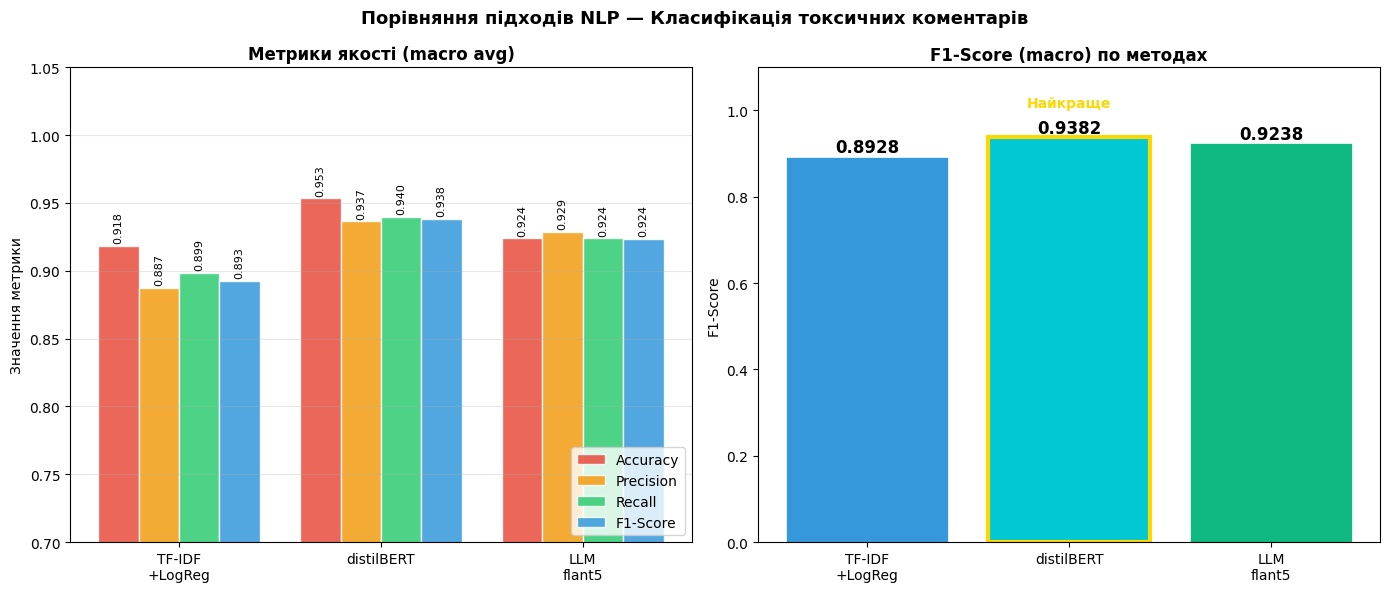

✅ Графік порівняння збережено: comparison_all_levels.png


In [36]:
# ── Візуальне порівняння метрик ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Порівняння підходів NLP — Класифікація токсичних коментарів',
             fontsize=13, fontweight='bold')

methods  = ['TF-IDF\n+LogReg', 'distilBERT', f'LLM\n{LLM_PROVIDER}']
colors   = ['#3498db', '#00C9D4', '#10B981']
metrics_vals = {
    'Accuracy':  [acc_l1, acc_l2, acc_l3],
    'Precision': [prec_l1, prec_l2, prec_l3],
    'Recall':    [rec_l1, rec_l2, rec_l3],
    'F1-Score':  [f1_l1, f1_l2, f1_l3],
}

# Grouped bar chart
x = np.arange(len(methods))
width = 0.2
metric_colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

for i, (metric, vals) in enumerate(metrics_vals.items()):
    bars = axes[0].bar(x + i * width, vals, width,
                        label=metric, color=metric_colors[i], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.002,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(methods)
axes[0].set_ylim(0.7, 1.05)
axes[0].set_ylabel('Значення метрики')
axes[0].set_title('Метрики якості (macro avg)', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

# Radar chart / F1 порівняння
f1_vals = [f1_l1, f1_l2, f1_l3]
bars2 = axes[1].bar(methods, f1_vals, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('F1-Score (macro) по методах', fontweight='bold')
axes[1].set_ylabel('F1-Score')
for bar, v in zip(bars2, f1_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f'{v:.4f}', ha='center', fontweight='bold', fontsize=12)

# Highlight best
best_idx = f1_vals.index(max(f1_vals))
bars2[best_idx].set_edgecolor('gold')
bars2[best_idx].set_linewidth(3)
axes[1].annotate('Найкраще', xy=(best_idx, max(f1_vals)),
                  xytext=(best_idx, max(f1_vals) + 0.07),
                  ha='center', fontsize=10, color='gold', fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_all_levels.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Графік порівняння збережено: comparison_all_levels.png')

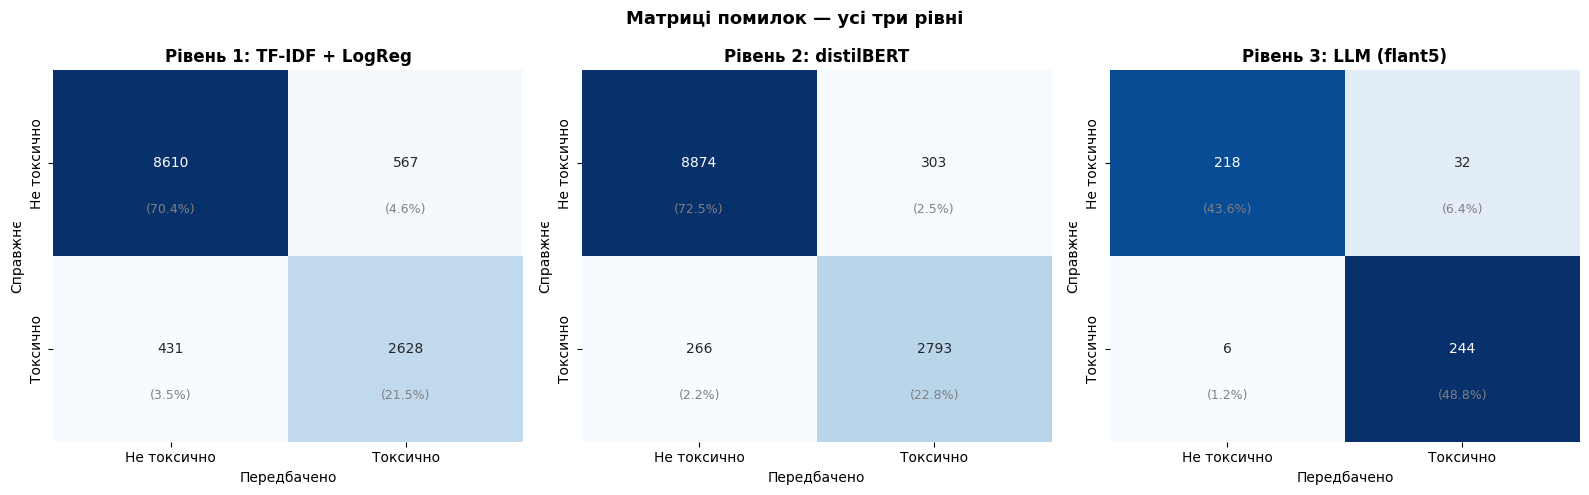

In [37]:
# ── Матриці помилок усіх рівнів ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Матриці помилок — усі три рівні', fontsize=13, fontweight='bold')

plot_confusion_matrix(y_test, y_pred_l1, 'Рівень 1: TF-IDF + LogReg', axes[0])
plot_confusion_matrix(y_true_l2, y_pred_l2, 'Рівень 2: distilBERT', axes[1])
plot_confusion_matrix(y_eval_arr, y_pred_l3, f'Рівень 3: LLM ({LLM_PROVIDER})', axes[2])

plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150)
plt.show()

In [38]:
# ── Фінальний висновок ───────────────────────────────────
best_method_idx = [f1_l1, f1_l2, f1_l3].index(max(f1_l1, f1_l2, f1_l3))
best_names = ['TF-IDF + Logistic Regression', 'distilBERT', f'LLM {LLM_PROVIDER}']

print('=' * 70)
print('ВИСНОВКИ ЛАБОРАТОРНОЇ РОБОТИ')
print('=' * 70)
print(f'\nНайкращий метод за F1-Score: {best_names[best_method_idx]}')
print(f'  F1 = {max(f1_l1, f1_l2, f1_l3):.4f}')
print()
print('Рекомендації щодо вибору методу:')
print('  - Обмежені ресурси / CPU only   → TF-IDF + LogReg (швидко, просто)')
print('  - Максимальна якість / є GPU    → distilBERT fine-tuning')
print('  - Прототипування / без навчання → LLM Few-Shot API')
print()
print(f'Покращення distilBERT vs TF-IDF: +{(f1_l2 - f1_l1)*100:.1f}% F1')
print(f'Час навчання L1: {train_time_l1:.0f}с | L2: {train_time_l2/60:.0f}хв | L3: 0 (API)')

ВИСНОВКИ ЛАБОРАТОРНОЇ РОБОТИ

Найкращий метод за F1-Score: distilBERT
  F1 = 0.9382

Рекомендації щодо вибору методу:
  - Обмежені ресурси / CPU only   → TF-IDF + LogReg (швидко, просто)
  - Максимальна якість / є GPU    → distilBERT fine-tuning
  - Прототипування / без навчання → LLM Few-Shot API

Покращення distilBERT vs TF-IDF: +4.5% F1
Час навчання L1: 20с | L2: 60хв | L3: 0 (API)
